# Using R inside Python notebooks

While Python has solidified its position as the powerhouse for high-performance single-cell preprocessing and deep learning integration (thanks to the Scanpy and scvi-tools ecosystems), the R environment remains an indispensable titan of statistical bioinformatics.

The primary reason we bridge these two worlds is Bioconductor: a massive, peer-reviewed repository of over 2,000 packages that has served as the gold standard for genomic analysis for decades. Many "gold-standard" statistical methods—such as the rigorous differential expression testing of DESeq2, complex multi-modal integration in Seurat, or specialized trajectory inference tools—are natively built for R. Furthermore, R’s visualization capabilities via ggplot2 and its derivatives often provide a level of "publication-ready" aesthetic control that is difficult to replicate elsewhere (even though `plotnine` is getting close). In reproducible bioinformatics, we want to run and render seamless reports utilizing packages across languages, based on scientific merit. By mastering interoperability, you are building a hybrid pipeline that leverages Python’s computational speed for data crunching and R’s statistical depth for biological interpretation.

## On `rpy2` and language interoperability

In this and the upcoming notebooks, we demonstrate Python workflows and Python-based interoperability due to the wide availability of single-cell multi-omics integration methods in Python. The natural choice for interoperability is therefore `rpy2`, to call R. However, `rpy2` is verbose, and users must account for many technical details. Therefore, we are using a package from GitHub `bioc2ri`, which is a convenience layer around `rpy2`, with easier access to functionalites, and pre-amde conversions to R-objects.

As R has been introduced and utilized in the previous lectures, we are focusing on the Python-side interoperability. However, for all tasks, experienced users may go R-first, and use `reticulate` for calling Python from R, if desired. 

This and all upcoming notebooks can of course be used either with conda-env or inside docker. We found, that language interoperability with `rpy2` is much easier with docker + uv-installed Python environment. 

As an example for a conda-env, you may find the respective configuration `.yaml`-file in `00_prep_python_uv/conda_envs/lecture__r_interop.yaml`. Otherwise, the `uv`-venv is installed inside `00_prep_python_uv/`. 

In [1]:
import os
import sys
%load_ext autoreload
%autoreload 2

### This is only necessary when using conda in docker containers:


# Get the directory of the current Conda environment
# conda_prefix = sys.prefix

# # Force R_HOME to point to the R inside this Conda environment'
# os.environ['R_HOME'] = f"{conda_prefix}/lib/R"

# # Optional: Ensure the Conda R bin is at the front of the PATH
# os.environ['PATH'] = f"{conda_prefix}/bin:" + os.environ.get('PATH', '')
###



### Load the convenience library
# Now you can safely import rpy2 or your package
from bioc2ri.lazy_r_env import get_r_environment
r = get_r_environment()

from bioc2ri import pandas_plugin
import pandas as pd

## Installing packages

When using a `conda`-based R for interoperability, we would install R packages with conda, as you may see in the configuration yaml-file for this notebook (see above). If using `uv`, with or without docker, we are just using R installed on the computer. You could start RStudio and install the packages there, or start the terminal, and install whatever you need.

```
R

install.packages('tidyverse')
BiocManager::install('scrapper')
```

## Differential Expression Example

This section of the notebook illustrates the "Hybrid Pipeline" in action. We will perform the heavy lifting of loading and subsetting in Python, then hand the data over to the Bioconductor ecosystem to run a statistically rigorous Differential Expression (DE) analysis using `edgeR` and `limma`.

**Data Preparation** 

Fetching the "Airway" Dataset via R:
We will use R to load the data, then use your core_eng to bring it into a Python AnnData object. This is a great "meta" demonstration: using R as a data provider for Python.

This section demonstrates the core of our interoperability workflow: fetching a "Gold Standard" dataset from the R Bioconductor ecosystem and mapping it into a Python AnnData object.

In this example, we use the Airway dataset, which consists of human airway smooth muscle cells treated with dexamethasone. Since this is a classic bulk RNA-seq dataset natively packaged for R, we use our custom engine to "translate" the R object into a format compatible with Python's single-cell ecosystem.

**Key Concepts in this Cell**:

1. Object Mapping: We are converting an R SingleCellExperiment (SCE) into a Python AnnData object. Our custom engine, core_eng, handles the complex task of ensuring that R's "assays" become Python "layers" and R's "colData" becomes Python "obs".

2. The Matrix Transpose: One of the most critical steps in bioinformatics interoperability is handling memory layout.

    - R (Bioconductor) stores data as Genes (Rows) × Samples (Columns).

    - Python (Scanpy/AnnData) stores data as Samples (Rows) × Genes (Columns). Our engine automatically transposes the matrices during the r2py call to ensure the biology remains aligned.

3. Layer-Centric Design: By default, Python's .X slot is often used for the "currently active" data (like normalized or log-transformed values). To maintain transparency, we move the raw counts into a named layer (adata.layers["counts"]) and leave .X empty. This forces downstream analysis steps to be explicit about which data layer they are using.

In [2]:
from rpy2.robjects import r
from rpy2.robjects.packages import importr
import anndata as ad
from bioc2ri.anndata_sce_plugin import anndata2sce_plugin
from bioc2ri.pandas_plugin import pandas_plugin

# Initialize the conversion engine
core_eng = anndata2sce_plugin()
pd_eng = pandas_plugin()

# 1. Load the data in R
# airway contains transcriptomic data from human airway smooth muscle cells
airway_pkg = importr("airway")
r("data(airway)")

# Coerce the RangedSummarizedExperiment to a SingleCellExperiment for our engine
r_airway = r("as(airway, 'SingleCellExperiment')")

# 2. Convert to AnnData using the r2py (R-to-Python) method
# This handles the transposition and metadata mapping automatically
adata = core_eng.r2py(r_airway)

# 3. Clean up: Move the primary assay from .X to a named 'counts' layer
if "counts" not in adata.layers and "X" in adata.layers:
    adata.layers["counts"] = adata.layers.pop("X")

# Clear .X to demonstrate a layer-centric workflow
adata.X = None 

print(f"Loaded Airway dataset: {adata.n_obs} samples, {adata.n_vars} genes.")
print(f"Metadata columns: {adata.obs.columns.tolist()}")


# Filter genes with zero counts across all samples
# Note: Since data is in .layers['counts'], we check there
gene_mask = adata.layers['counts'].sum(axis=0) > 0
adata = adata[:, gene_mask].copy()

# Ensure 'dex' (the treatment) is a category for R factors
adata.obs['dex'] = pd.Categorical(adata.obs['dex'])

print(f"Post-filtering: {adata.n_vars} genes remaining.")

(8, 9)
(63677, 10)
Loaded Airway dataset: 8 samples, 63677 genes.
Metadata columns: ['SampleName', 'cell', 'dex', 'albut', 'Run', 'avgLength', 'Experiment', 'Sample', 'BioSample']
Post-filtering: 33469 genes remaining.


Moving to Interactive R: IPython Magics

While the engine handles the data transfer, we can also change how we write code.

By loading the rpy2.ipython extension, we can turn any notebook cell into an R console using the %%R command. This is perfect for when you want to use R for a specific task (like plotting a quick ggplot2) without leaving your Python environment.

In [3]:
# Load IPython magic:
%load_ext rpy2.ipython

Now that we have our data cleaned and organized in Python, we need to "hand it back" to the R environment to perform the statistical testing.

This step involves two distinct actions: Translation and Assignment.

1. Translation: Python → R (py2r)The first line, r_sce = core_eng.py2r(adata), is where our engine performs its most critical task. It takes the Python AnnData object and rebuilds it as a native R SingleCellExperiment.

During this process, the engine automatically:
- Transposes the data: It flips the $Samples \times Genes$ matrix back into the $Genes \times Samples$ format that Bioconductor expects.
- Maps Metadata: It ensures that your adata.obs (sample information like treatment groups) is converted into an R DataFrame that R's statistical models can read.

2. Assignment: Pinning the Variable in R: The second line, `r.ro.r.assign("sce", r_sce)`, is what actually "pushes" the data across the boundary.

In programming terms, we are taking the R object we just created in Python memory and assigning it to a global variable named "sce" inside the R interpreter. This is like "pinning" a document to a shared bulletin board; once it's assigned, any subsequent R code—whether run via a magic cell (%%R) or a script—will be able to see and use the object sce.

In [4]:
# 1. Translate the Python AnnData object into a native R SingleCellExperiment
# This handles the memory layout flip (transposition) automatically.
r_sce = core_eng.py2r(adata)

# 2. Assign the object to a variable named "sce" in the R global environment.
# Now, any R code we run will recognize "sce" as our dataset.
r.assign("sce", r_sce)

<rpy2.robjects.methods.RS4 object at 0x7bce3c45fcd0> [25]
R classes: ('SingleCellExperiment',)

**Statistical Modeling in R (limma-voom)**

Once the data is "pushed" to the R environment, we use the %%R cell magic to run a specialized Bioconductor workflow.

**The Interoperability Logic:**

- Direct Access: R recognizes the sce object we created in Python, allowing us to use the dex metadata column directly in our statistical design.
- Specialized Tools: We use edgeR for data containerization and limma-voom for the analysis.
- The Voom Advantage: It transforms raw counts into weighted log-CPM values, making them compatible with fast linear modeling while accounting for the mean-variance relationship typical of RNA-seq.

**Workflow Summary:**

1. Filter & Normalize: Remove low-count genes and normalize library sizes.
2. Model Design: Define the experimental comparison (Treated vs. Control).
3. Voom Transformation: Convert counts to weighted linear values.
4. Linear Fit: Use eBayes to share statistical power across all genes, stabilizing the results even with small sample sizes.

By running this in an R magic cell, we leverage R's industry-standard biostatistics without ever leaving our Python-based notebook.

In [5]:
%%R
library(edgeR)
library(limma)

# 1. Prepare the DGEList from our SCE
# We pull the 'counts' assay we moved into R
dge <- DGEList(counts = assay(sce, "counts"))

# 2. Filter and Normalize
# filterByExpr automatically removes genes with too few counts to be statistically useful
keep <- filterByExpr(dge, group = sce$dex)
dge <- dge[keep, , keep.lib.sizes=FALSE]
dge <- calcNormFactors(dge)

# 3. Define the Design Matrix
# We use the 'dex' column directly from the SingleCellExperiment metadata
design <- model.matrix(~ dex, data = colData(sce))

# 4. The voom transformation
# This converts counts to log2-counts per million (logCPM) 
# and calculates the mean-variance weights.
v <- voom(dge, design, plot = FALSE)

# 5. Linear Modeling with limma
# fit: fits a linear model for each gene
# eBayes: performs empirical Bayes shrinkage on the variances
fit <- lmFit(v, design)
fit <- eBayes(fit)

# 6. Extract Results
# coef=2 corresponds to the dex treatment effect
res_df <- topTable(fit, coef = 2, n = Inf, sort.by = "P")

Loading required package: limma

Attaching package: ‘limma’

The following object is masked from ‘package:BiocGenerics’:

    plotMA


Attaching package: ‘edgeR’

The following objects are masked from ‘package:SingleCellExperiment’:

    cpm, tpm



In [6]:
# 3. Bring results back to Python
# Our pandas_plugin handles the conversion of the results table
de_results = pd_eng.r2py(r["res_df"])
display(de_results.head())

,logFC,AveExpr,t,P.Value,adj.P.Val,B
ENSG00000152583,-4.574855,4.167526,-18.527604,2.194744e-08,0.000204,9.297282
ENSG00000134686,-1.381139,6.839533,-16.899763,4.853259e-08,0.000204,9.209304
ENSG00000179094,-3.185870,4.421045,-16.593010,5.681830e-08,0.000204,8.877958
ENSG00000125148,-2.198075,7.024695,-16.376151,6.362189e-08,0.000204,8.942174
ENSG00000148175,-1.440288,8.856653,-16.359733,6.417269e-08,0.000204,8.799960


To wrap up the workflow, we compare the visualization capabilities of both ecosystems. One of the most powerful aspects of this interoperability is that you can now use the Grammar of Graphics in both languages.

**The Grammar of Graphics: plotnine vs. ggplot2**
Historically, Python users had to switch between matplotlib and seaborn, which use different logic than R's ggplot2. However, plotnine has matured significantly and is now a high-quality, feature-complete implementation of the Grammar of Graphics for Python.

This means you can use nearly identical syntax to generate publication-quality plots in either environment, making the transition between Python and R practically seamless for visualization.

1. Visualization in Python (plotnine)

We’ll start by creating a Volcano Plot using plotnine. Notice how the syntax mirrors R almost perfectly.

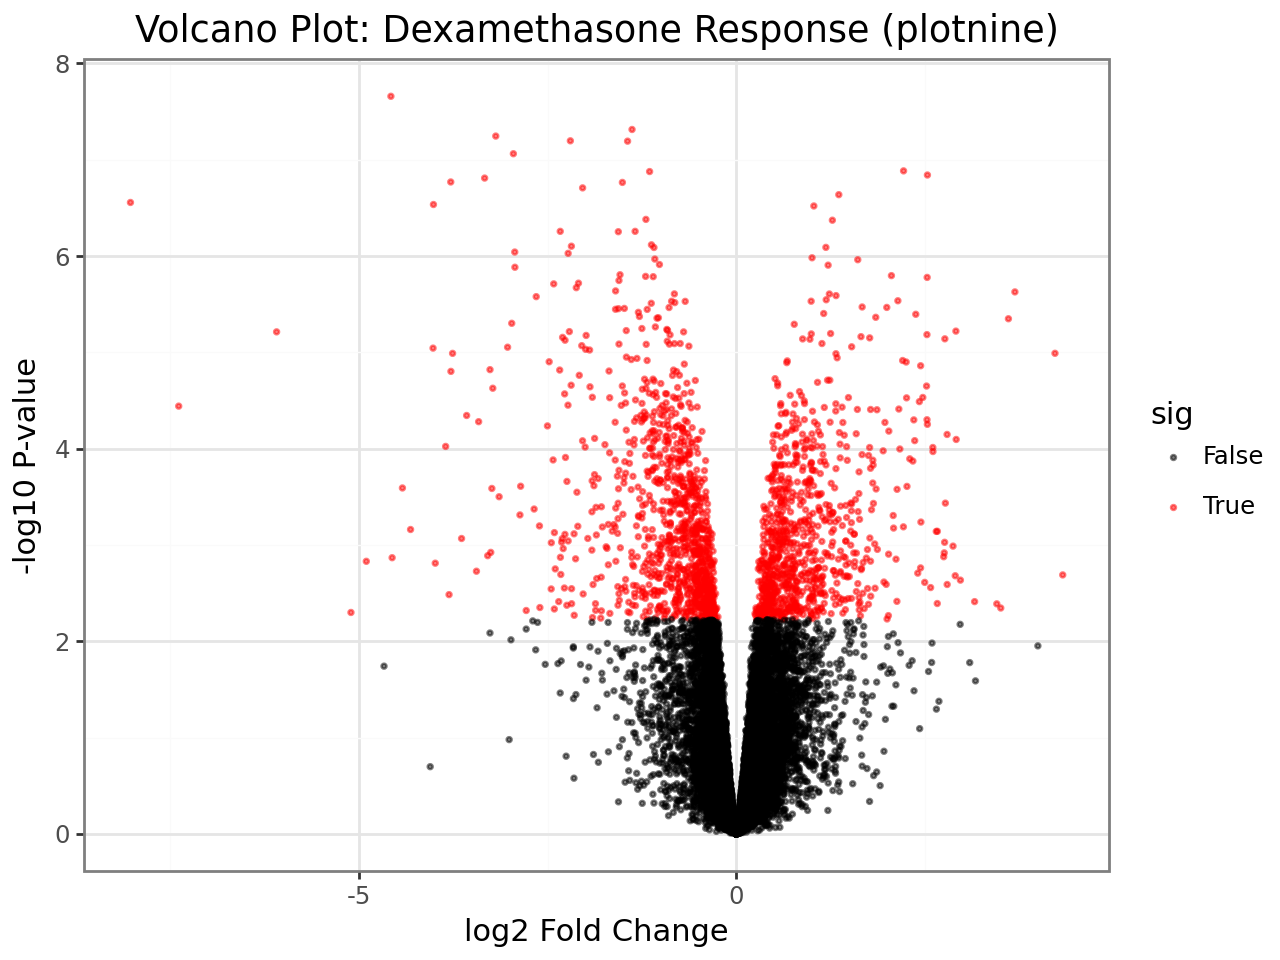

In [7]:
from plotnine import *
import numpy as np

# Adding a significance column for coloring
de_results['sig'] = de_results['adj.P.Val'] < 0.05
de_results["neg_log10"] = np.log10(de_results["P.Value"]) * -1

p = (
    ggplot(de_results, aes(x='logFC', y='neg_log10', color='sig'))
    + geom_point(alpha=0.5, size=0.5)
    + scale_color_manual(values=['black', 'red'])
    + theme_bw()
    + labs(
        title="Volcano Plot: Dexamethasone Response (plotnine)",
        x="log2 Fold Change",
        y="-log10 P-value"
    )
)
p

2. Visualization in R (ggplot2)

To demonstrate the parity, we run the same visualization logic inside our R magic cell using the original res_df.

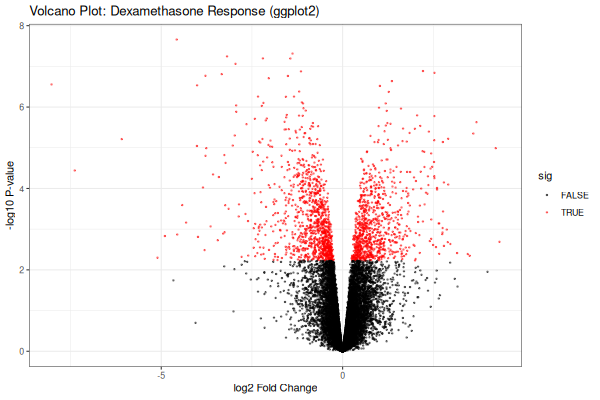

In [8]:
%%R -w 600 -h 400
library(ggplot2)

# Ensure significance is a factor for plotting
res_df$sig <- res_df$adj.P.Val < 0.05

ggplot(res_df, aes(x=logFC, y=-log10(P.Value), color=sig)) +
  geom_point(alpha=0.5, size=0.5) +
  scale_color_manual(values=c("black", "red")) +
  theme_bw() +
  labs(
    title="Volcano Plot: Dexamethasone Response (ggplot2)",
    x="log2 Fold Change",
    y="-log10 P-value"
  )